In [23]:
!pip install --upgrade pip
!pip install numpy
!pip install tensorflow keras

type(images)=<class 'numpy.ndarray'>, type(labels)=<class 'numpy.ndarray'>
images.shape=(1000, 784), labels.shape=(1000,)
weights_0_1.shape=(784, 100), weights_1_2.shape=(100, 10)
 I:0 Train-Acc:0.156 Test-Acc:0.394
 I:1 Train-Acc:0.395 Test-Acc:0.584
 I:2 Train-Acc:0.572 Test-Acc:0.637
 I:3 Train-Acc:0.619 Test-Acc:0.657
 I:4 Train-Acc:0.677 Test-Acc:0.668
 I:5 Train-Acc:0.683 Test-Acc:0.676
 I:6 Train-Acc:0.701 Test-Acc:0.684
 I:7 Train-Acc:0.717 Test-Acc:0.686
 I:8 Train-Acc:0.707 Test-Acc:0.686
 I:9 Train-Acc:0.725 Test-Acc:0.688
 I:10 Train-Acc:0.723 Test-Acc:0.686
 I:11 Train-Acc:0.722 Test-Acc:0.689
 I:12 Train-Acc:0.73 Test-Acc:0.691
 I:13 Train-Acc:0.726 Test-Acc:0.695
 I:14 Train-Acc:0.717 Test-Acc:0.696
 I:15 Train-Acc:0.729 Test-Acc:0.698
 I:16 Train-Acc:0.719 Test-Acc:0.697
 I:17 Train-Acc:0.724 Test-Acc:0.697
 I:18 Train-Acc:0.729 Test-Acc:0.699
 I:19 Train-Acc:0.725 Test-Acc:0.700
 I:20 Train-Acc:0.732 Test-Acc:0.702
 I:21 Train-Acc:0.731 Test-Acc:0.704
 I:22 Train-Acc:0

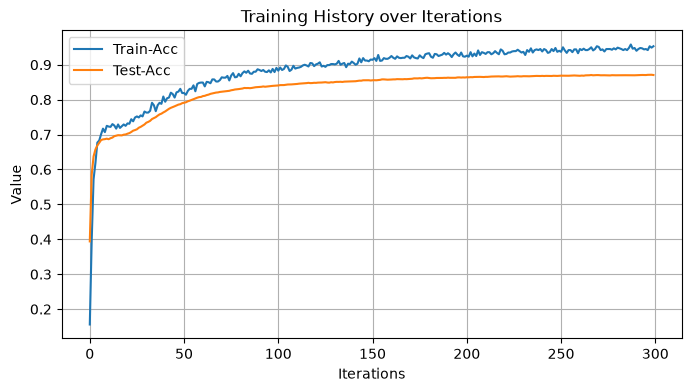

In [29]:
import sys, numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()
# 255 is the maximum value of a pixel in an image. Dividing by 255 normalizes the pixel values to be between 0 and 1.
# each deata point is an pixel that has a value between 0 and 255, where 0 is black and 255 is white. By dividing by 255, we scale the pixel values to be between 0 and 1, which is a common practice in machine learning to improve convergence during training.
images, labels = (x_train[0:1000].reshape(1000, 28 * 28) / 255,
                  y_train[0:1000])
print(f"type(images)={type(images)}, type(labels)={type(labels)}")
print(f"images.shape={images.shape}, labels.shape={labels.shape}")

# 0,1,2,3,..,9
# 1000x10 matrix
one_hot_labels = np.zeros((len(labels), 10))
for i, label in enumerate(labels):
    one_hot_labels[i][label] = 1

# Goal Prediction: 0,1,2,3,..,9
labels = one_hot_labels

test_images = x_test.reshape(len(x_test), 28 * 28) / 255
test_labels = np.zeros((len(y_test), 10))
for i, label in enumerate(y_test):
    test_labels[i][label] = 1


def relu(x):
    return (x > 0) * x

def relu2derive(output):
    return output > 0

def tanh(x):
    return np.tanh(x)

def tanh2derive(output):
    return 1 - (output ** 2)

def softmax(x):
    temp = np.exp(x)
    return temp / np.sum(temp, axis=1, keepdims=True)

np.random.seed(1)

alpha, iterations, hidden_size = (2, 300, 100)
# 28x28 = 784
pixels_per_image, num_labels = (784, 10)

batch_size = 100

# -0.1 to 0.1
# 784x100 matrix
weights_0_1 = 0.02 * np.random.random((pixels_per_image, hidden_size)) - 0.01
# 100x10 matrix
weights_1_2 = 0.2 * np.random.random((hidden_size , num_labels)) - 0.1

print(f"weights_0_1.shape={weights_0_1.shape}, weights_1_2.shape={weights_1_2.shape}")
# print(f"weights_0_1=\n{weights_0_1}\nweights_1_2=\n{weights_1_2}")

# matlab
train_error = []
train_accuracy = []
test_error = []
test_accuracy = []

for j in range(iterations):
    correct_cnt = 0

    length = (int)(len(images) / batch_size)
    for i in range(length):
        batch_start, batch_end = ((i * batch_size), ((i + 1) * batch_size))

        # input layer is 100x784 (batch_size x pixels_per_image)
        layer_0 = images[batch_start:batch_end]
        # hidden layer is 100x100 (batch_size x hidden_size)
        ## 100x784 * 784x100 = 100x100
        layer_1 = tanh(np.dot(layer_0, weights_0_1))

        # fill out 0 or 1 randomly for each element in dropou_mask , which has the same shape as layeer_1.
        # 0: disabled (dropout)
        # 1: enabled
        # dropout rate is 0.5 (50%)
        dropout_mask = np.random.randint(2, size=layer_1.shape)
        # retain the same expected value of the output by scaling the enabled neurons by 2 (1 / (1 - dropout_rate) = 1 / (1 - 0.5) = 2)
        layer_1 *= dropout_mask * 2

        # prediction layer is 100x10
        # 100x100 * 100x10 = 100x10
        layer_2 = softmax(np.dot(layer_1, weights_1_2))

        for k in range(batch_size):
            goal_prediction = labels[batch_start+k:batch_start+k+1]
            correct_cnt += int(np.argmax(layer_2[k:k+1]) == np.argmax(goal_prediction))

        # Backpropagation
        # The derivative of the softmax function combined with the cross-entropy loss simplifies to (layer_2 - labels) / batch_size, which is used to compute the gradient for the output layer.
        layer_2_delta = (layer_2 - labels[batch_start:batch_end]) / (batch_size * layer_2.shape[0])
        layer_1_delta = layer_2_delta.dot(weights_1_2.T) * tanh2derive(layer_1)
        layer_1_delta *= dropout_mask

        weights_1_2 = weights_1_2 - alpha * layer_1.T.dot(layer_2_delta)
        weights_0_1 = weights_0_1 - alpha * layer_0.T.dot(layer_1_delta)

    test_correct_cnt = 0

    for i in range(len(test_images)):
        layer_0 = test_images[i:i+1]
        layer_1 = tanh(np.dot(layer_0, weights_0_1))
        layer_2 = np.dot(layer_1, weights_1_2)

        test_correct_cnt += int(np.argmax(layer_2) == np.argmax(test_labels[i:i+1]))

    sys.stdout.write(
        " I:" + str(j) + \
        " Train-Acc:" + str(correct_cnt / float(len(images)))[0:5] + \
        " Test-Acc:" + str(test_correct_cnt / float(len(test_images)))[0:5]
    )
    sys.stdout.write("\n")

    # matplotlib
    train_accuracy.append(correct_cnt / float(len(images)))
    test_accuracy.append(test_correct_cnt / float(len(test_images)))

plt.figure(figsize=(8, 4))
plt.plot(train_accuracy, label="Train-Acc")
plt.plot(test_accuracy, label="Test-Acc")
plt.xlabel("Iterations")
plt.ylabel("Value")
plt.title("Training History over Iterations")
plt.legend()
plt.grid(True)
plt.show()

